In [1]:
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras import datasets, layers, models

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import keras
from keras import backend as K
from keras.layers.core import Dense, Activation
from keras.metrics import categorical_crossentropy
#from keras.preprocessing.image import ImageDataGenerator
from keras.preprocessing import image
from keras.models import Model
from keras.applications import imagenet_utils
from keras.layers import Dense,GlobalAveragePooling2D
from keras.applications.mobilenet import preprocess_input
from IPython.display import Image

In [2]:
# download images to colab temp folder

import zipfile
import os

!wget --no-check-certificate \
    "https://github.com/rocktrees/CS4372/archive/refs/heads/master.zip" \
    -O "/tmp/monkeys.zip"


zip_ref = zipfile.ZipFile('/tmp/monkeys.zip', 'r')
zip_ref.extractall('/tmp')
zip_ref.close()

--2021-12-18 19:40:12--  https://github.com/rocktrees/CS4372/archive/refs/heads/master.zip
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://codeload.github.com/rocktrees/CS4372/zip/refs/heads/master [following]
--2021-12-18 19:40:12--  https://codeload.github.com/rocktrees/CS4372/zip/refs/heads/master
Resolving codeload.github.com (codeload.github.com)... 140.82.114.10
Connecting to codeload.github.com (codeload.github.com)|140.82.114.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/zip]
Saving to: ‘/tmp/monkeys.zip’

/tmp/monkeys.zip        [                <=> ] 547.00M  24.7MB/s    in 23s     

2021-12-18 19:40:35 (23.6 MB/s) - ‘/tmp/monkeys.zip’ saved [573573781]



#TEST/ PREPROCESSING IMAGES

#TEST END

In [ ]:
from tensorflow.keras.preprocessing import image_dataset_from_directory
get_pics =  image_dataset_from_directory

train = get_pics('/tmp/CS4372-master/training', batch_size=2, image_size=(224,224), label_mode='categorical')
val = get_pics('/tmp/CS4372-master/validation', batch_size=2, image_size=(224,224), label_mode='categorical')

Found 1097 files belonging to 10 classes.
Found 272 files belonging to 10 classes.


In [ ]:
# BUILD MODEL
from tensorflow.keras.applications.mobilenet import MobileNet

base_model2=MobileNet(input_shape=(224,224,3), weights='imagenet',include_top=False)

x=base_model2.output
x=GlobalAveragePooling2D()(x) 
x=Dense(200,activation='relu')(x)
x=Dense(350,activation='relu')(x)
x = tf.keras.layers.Dropout(0.2)(x)
preds=Dense(10,activation='softmax')(x)


17235968/17225924 [==============================] - 0s 0us/step


In [ ]:
model=Model(inputs=base_model2.input,outputs=preds)

In [ ]:
for layer in model.layers:
    layer.trainable=False

In [ ]:
#optimizer='Adam'
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=.0001),
             loss='categorical_crossentropy', metrics=['accuracy'])

model_loss, model_accuracy = model.evaluate(val)
print('Accuracy: ' + str(model_accuracy))


136/136 [==============================] - 5s 29ms/step - loss: 0.1077 - accuracy: 0.9816
Accuracy: 0.9816176295280457


In [ ]:
len(model.layers)

91

In [ ]:
# learn
history = model.fit(train, epochs=5, validation_data=val)

Epoch 1/5
549/549 [==============================] - 22s 36ms/step - loss: 0.0178 - accuracy: 0.9973 - val_loss: 0.1077 - val_accuracy: 0.9816
Epoch 2/5
549/549 [==============================] - 20s 37ms/step - loss: 0.0160 - accuracy: 0.9973 - val_loss: 0.1077 - val_accuracy: 0.9816
Epoch 3/5
549/549 [==============================] - 20s 37ms/step - loss: 0.0160 - accuracy: 0.9964 - val_loss: 0.1077 - val_accuracy: 0.9816
Epoch 4/5
549/549 [==============================] - 20s 36ms/step - loss: 0.0159 - accuracy: 0.9964 - val_loss: 0.1077 - val_accuracy: 0.9816
Epoch 5/5
549/549 [==============================] - 20s 36ms/step - loss: 0.0157 - accuracy: 0.9964 - val_loss: 0.1077 - val_accuracy: 0.9816


In [ ]:
# test model
test_loss, test_acc = model.evaluate(val)

136/136 [==============================] - 5s 32ms/step - loss: 0.1077 - accuracy: 0.9816


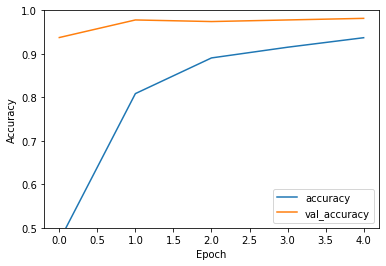

In [ ]:
# Evaluate
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')


5


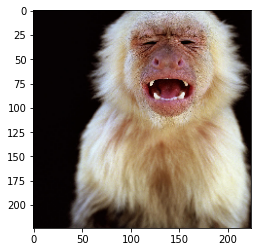

In [ ]:
#testing a single image

def image_process(img_path, show=False):

    img = image.load_img(img_path, target_size=(224, 224))
    img_tensor = image.img_to_array(img)                   
    img_tensor = np.expand_dims(img_tensor, axis=0)  
    return img_tensor
  
path = '/tmp/CS4372-master/validation/n8/n8010.jpg'

new_image = image_process(path)

plt.imshow(image.load_img(path, target_size=(224, 224)))

pred = model.predict(new_image)

print(np.where(pred[0] == max(pred[0]))[0][0])
